# VGG16 Transfer Learning for Bearing Classification

This Colab notebook classifies bearing images into two classes:

- `defective`
- `good`

It covers the complete workflow:

1. Load the labeled dataset from Google Drive.
2. Inspect and preprocess the images.
3. Load pretrained VGG16.
4. Freeze the pretrained model and train only a new output layer.
5. Unfreeze the final convolution block and fine-tune it.
6. Evaluate the final model on an unseen test set.
7. Display predictions and misclassified images.
8. Predict a newly uploaded bearing image.
9. Save and reload the trained model.

Expected folder structure:

```text
bearing_dataset/
├── train/
│   ├── defective/
│   └── good/
├── val/
│   ├── defective/
│   └── good/
└── test/
    ├── defective/
    └── good/
```

## 1. Select a GPU runtime

In Colab select:

```text
Runtime -> Change runtime type -> GPU
```

In [ ]:
import torch
print(torch.cuda.__doc__)


This package adds support for CUDA tensor types.

It implements the same function as CPU tensors, but they utilize
GPUs for computation.

It is lazily initialized, so you can always import it, and use
:func:`is_available()` to determine if your system supports CUDA.

:ref:`cuda-semantics` has more details about working with CUDA.



In [ ]:
torch.cuda.is_available()
torch.cuda.get_device_name()

'Tesla T4'

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available : True
GPU name       : Tesla T4


## 2. Import libraries and set reproducibility

In [ ]:
import copy
import random
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import vgg16, VGG16_Weights

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. Mount Google Drive and locate the dataset

The notebook accepts either the ZIP file created earlier or an extracted dataset folder.
Edit the paths only when your Drive location is different.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

DRIVE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/CNN_Transfer_Learning"
)

DRIVE_ZIP_PATH = (
    DRIVE_PROJECT_DIR
    / "bearing_dataset_classification.zip"
)

DRIVE_DATASET_DIR = (
    DRIVE_PROJECT_DIR
    / "bearing_dataset"
)

LOCAL_DATASET_DIR = Path(
    "/content/bearing_dataset"
)

print("ZIP path   :", DRIVE_ZIP_PATH)
print("Drive folder:", DRIVE_DATASET_DIR)
print("Local folder:", LOCAL_DATASET_DIR)

Mounted at /content/drive
ZIP path   : /content/drive/MyDrive/CNN_Transfer_Learning/bearing_dataset_classification.zip
Drive folder: /content/drive/MyDrive/CNN_Transfer_Learning/bearing_dataset
Local folder: /content/bearing_dataset


## 4. Copy or extract the dataset into the Colab runtime

In [ ]:
def has_required_splits(directory):
    directory = Path(directory)
    return all(
        (directory / split_name).exists()
        for split_name in ["train", "val", "test"]
    )


if has_required_splits(LOCAL_DATASET_DIR):
    print("Dataset is already available locally.")

elif DRIVE_ZIP_PATH.exists():
    print("Extracting the dataset ZIP file...")
    shutil.unpack_archive(
        str(DRIVE_ZIP_PATH),
        "/content"
    )

elif has_required_splits(DRIVE_DATASET_DIR):
    print("Copying the dataset folder from Drive...")
    shutil.copytree(
        DRIVE_DATASET_DIR,
        LOCAL_DATASET_DIR
    )

else:
    raise FileNotFoundError(
        "Dataset not found. Check DRIVE_ZIP_PATH or DRIVE_DATASET_DIR."
    )

if not has_required_splits(LOCAL_DATASET_DIR):
    raise RuntimeError(
        "Expected train, val, and test folders were not found."
    )

print("Dataset ready at:", LOCAL_DATASET_DIR)

Extracting the dataset ZIP file...
Dataset ready at: /content/bearing_dataset


## 5. Verify the dataset and count images

In [ ]:
EXPECTED_SPLITS = ["train", "val", "test"]
EXPECTED_CLASSES = ["defective", "good"]
VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

for split_name in EXPECTED_SPLITS:
    print(f"\n{split_name.upper()}")

    for class_name in EXPECTED_CLASSES:
        class_dir = (
            LOCAL_DATASET_DIR
            / split_name
            / class_name
        )

        if not class_dir.exists():
            raise FileNotFoundError(
                f"Missing folder: {class_dir}"
            )

        image_paths = [
            path
            for path in class_dir.rglob("*")
            if path.is_file()
            and path.suffix.lower() in VALID_EXTENSIONS
        ]

        print(
            f"{class_name:<12}: "
            f"{len(image_paths)} images"
        )

        if len(image_paths) == 0:
            raise RuntimeError(
                f"No images found in {class_dir}"
            )


TRAIN
defective   : 2193 images
good        : 552 images

VAL
defective   : 91 images
good        : 22 images

TEST
defective   : 92 images
good        : 23 images


## 6. Display raw samples

Inspecting the data can reveal wrong labels, repeated images, unrealistic examples, lighting differences, and background bias.

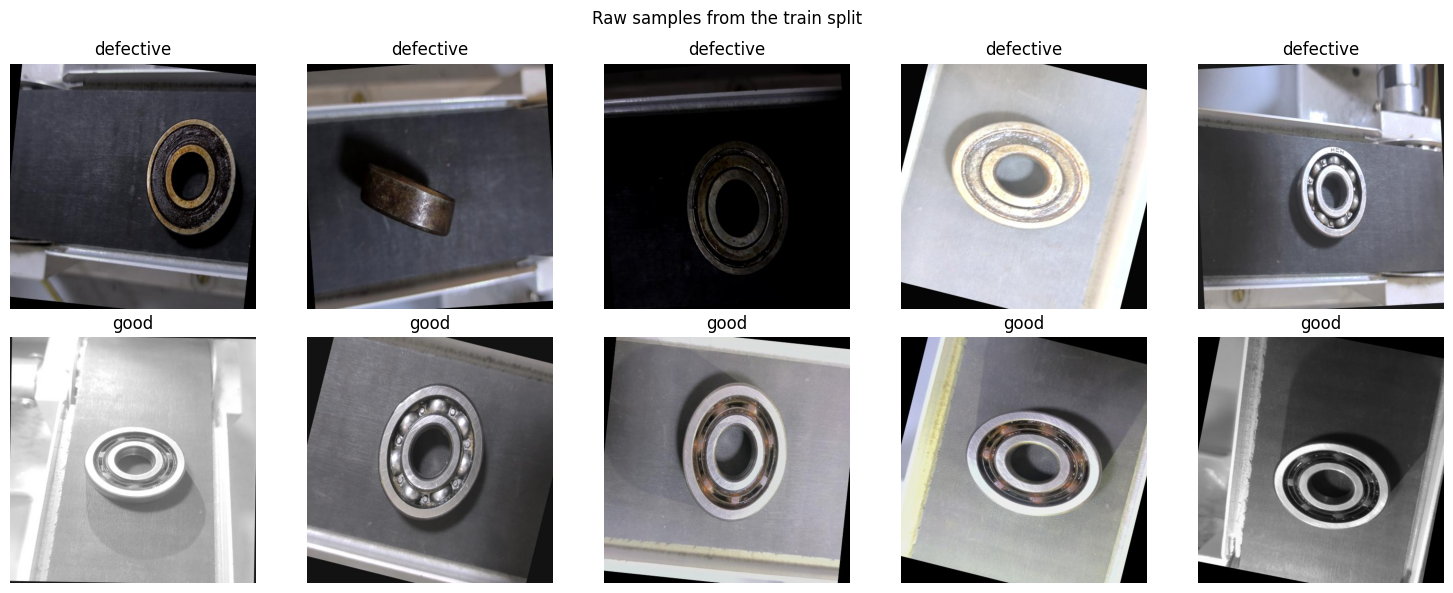

In [ ]:
def show_raw_samples(
    dataset_root,
    split_name="train",
    samples_per_class=5
):
    fig, axes = plt.subplots(
        len(EXPECTED_CLASSES),
        samples_per_class,
        figsize=(15, 6)
    )

    for row, class_name in enumerate(EXPECTED_CLASSES):
        class_dir = (
            Path(dataset_root)
            / split_name
            / class_name
        )

        image_paths = [
            path
            for path in class_dir.rglob("*")
            if path.is_file()
            and path.suffix.lower() in VALID_EXTENSIONS
        ]

        selected = random.sample(
            image_paths,
            min(samples_per_class, len(image_paths))
        )

        for column in range(samples_per_class):
            axis = axes[row, column]

            if column < len(selected):
                image = Image.open(
                    selected[column]
                ).convert("RGB")

                axis.imshow(image)
                axis.set_title(class_name)

            axis.axis("off")

    plt.suptitle(
        f"Raw samples from the {split_name} split"
    )
    plt.tight_layout()
    plt.show()


show_raw_samples(LOCAL_DATASET_DIR)

## 7. Define image transformations

Training images receive moderate random augmentation. Validation and test images use deterministic preprocessing. The ImageNet mean and standard deviation match the pretrained VGG16 input convention.

In [ ]:
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

USE_HORIZONTAL_FLIP = True

training_steps = [
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00)
    ),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    )
]

if USE_HORIZONTAL_FLIP:
    training_steps.append(
        transforms.RandomHorizontalFlip(p=0.5)
    )

training_steps.extend([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

train_transform = transforms.Compose(
    training_steps
)

evaluation_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print(train_transform)
print()
print(evaluation_transform)

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
img = '/content/bearing_dataset/train/good/1004_IMG_20260430_120824_jpg.rf.0858124776cecfdf9b03d48be592f65e.jpg'



## 8. Create datasets and print the class mapping

In [ ]:
train_dataset = datasets.ImageFolder(
    LOCAL_DATASET_DIR / "train",
    transform=train_transform
)

validation_dataset = datasets.ImageFolder(
    LOCAL_DATASET_DIR / "val",
    transform=evaluation_transform
)

test_dataset = datasets.ImageFolder(
    LOCAL_DATASET_DIR / "test",
    transform=evaluation_transform
)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
number_of_classes = len(class_names)

print("Classes        :", class_names)
print("Class mapping  :", class_to_idx)
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images    :", len(test_dataset))

assert set(class_names) == {"defective", "good"}
assert validation_dataset.class_to_idx == class_to_idx
assert test_dataset.class_to_idx == class_to_idx

Classes        : ['defective', 'good']
Class mapping  : {'defective': 0, 'good': 1}
Training images: 2745
Validation images: 113
Test images    : 115


## 9. Inspect the training class distribution

defective   : 2193
good        : 552


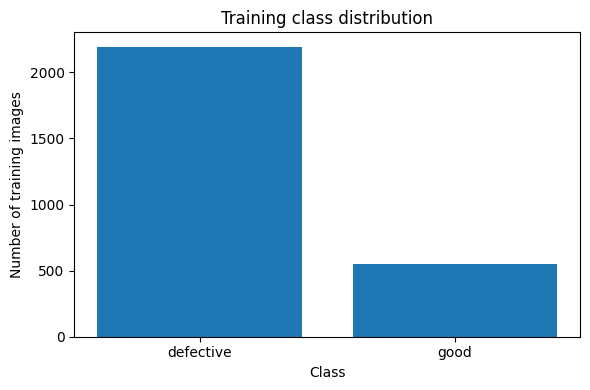

In [ ]:
train_targets = torch.tensor(
    train_dataset.targets
)

class_counts = torch.bincount(
    train_targets,
    minlength=number_of_classes
)

for class_index, class_name in enumerate(class_names):
    print(
        f"{class_name:<12}: "
        f"{class_counts[class_index].item()}"
    )

plt.figure(figsize=(6, 4))
plt.bar(class_names, class_counts.numpy())
plt.xlabel("Class")
plt.ylabel("Number of training images")
plt.title("Training class distribution")
plt.tight_layout()
plt.show()

## 10. Create data loaders and display a transformed batch

In [ ]:
BATCH_SIZE = 8
NUMBER_OF_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUMBER_OF_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Training batches  :", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches      :", len(test_loader))

Training batches  : 344
Validation batches: 15
Test batches      : 15


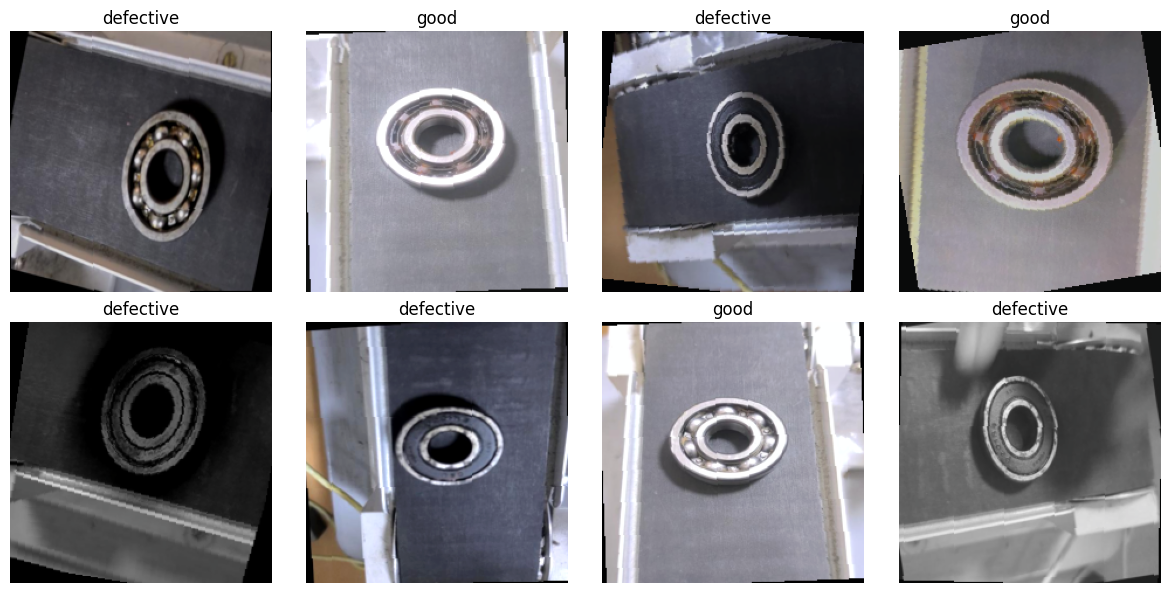

Image batch shape: torch.Size([8, 3, 224, 224])
Label batch shape: torch.Size([8])


In [ ]:
def denormalize(image_tensor):
    image = image_tensor.cpu().numpy()
    image = np.transpose(image, (1, 2, 0))
    image = image * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(image, 0, 1)


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for index in range(min(8, len(images))):
    axes[index].imshow(
        denormalize(images[index])
    )
    axes[index].set_title(
        class_names[labels[index].item()]
    )
    axes[index].axis("off")

plt.tight_layout()
plt.show()

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Stage 1: Fixed Feature Extraction

The pretrained VGG16 parameters are frozen. Only a new two-class output layer is trained.

# VGG MODEL Architecture


## 11. Load pretrained VGG16 and inspect its main sections

In [ ]:
weights = VGG16_Weights.DEFAULT
model = vgg16(weights=weights)



Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 80.1MB/s]


In [ ]:
print(model.features.__doc__)

A sequential container.

    Modules will be added to it in the order they are passed in the
    constructor. Alternatively, an ``OrderedDict`` of modules can be
    passed in. The ``forward()`` method of ``Sequential`` accepts any
    input and forwards it to the first module it contains. It then
    "chains" outputs to inputs sequentially for each subsequent module,
    finally returning the output of the last module.

    The value a ``Sequential`` provides over manually calling a sequence
    of modules is that it allows treating the whole container as a
    single module, such that performing a transformation on the
    ``Sequential`` applies to each of the modules it stores (which are
    each a registered submodule of the ``Sequential``).

    What's the difference between a ``Sequential`` and a
    :class:`torch.nn.ModuleList`? A ``ModuleList`` is exactly what it
    sounds like--a list for storing ``Module`` s! On the other hand,
    the layers in a ``Sequential`` are connecte

In [ ]:
#type(model.features)

In [ ]:
print("VGG16 FEATURE EXTRACTOR")
print(model.features)


VGG16 FEATURE EXTRACTOR
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Co

* Block 1 (2 layers): 64 filters each → 64 + 64 = 128 filters
* Block 2 (2 layers): 128 filters each → 128 + 128 = 256 filters
* Block 3 (3 layers): 256 filters each → 256 × 3 = 768 filters
* Block 4 (3 layers): 512 filters each → 512 × 3 = 1,536 filters
* Block 5 (3 layers): 512 filters each → 512 × 3 = 1,536 filters
* Total filters (kernels): 128 + 256 + 768 + 1536 + 1536 = ???

In [ ]:
print("VGG16 AVERAGE POOLING")
print(model.avgpool)

VGG16 AVERAGE POOLING
AdaptiveAvgPool2d(output_size=(7, 7))


In [ ]:
print("VGG16 CLASSIFIER")
print(model.classifier)

VGG16 CLASSIFIER
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


In [ ]:
print("Original final layer:")
print(model.classifier[6])

print("\nAdaptive average pooling:")
print(model.avgpool)

Original final layer:
Linear(in_features=4096, out_features=1000, bias=True)

Adaptive average pooling:
AdaptiveAvgPool2d(output_size=(7, 7))


In [ ]:
dummy_image = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    feature_maps = model.features(dummy_image)
    pooled_maps = model.avgpool(feature_maps)
    flattened = torch.flatten(pooled_maps, start_dim=1)

print("Input shape          :", dummy_image.shape)
print("After features       :", feature_maps.shape)
print("After avgpool        :", pooled_maps.shape)
print("After flattening     :", flattened.shape)

Input shape          : torch.Size([1, 3, 224, 224])
After features       : torch.Size([1, 512, 7, 7])
After avgpool        : torch.Size([1, 512, 7, 7])
After flattening     : torch.Size([1, 25088])


For a 224 x 224 input, the feature extractor produces 512 feature maps of size 7 x 7. Flattening gives:

$$512 	* 7 	* 7 = 25088$$

## 12. Freeze all pretrained parameters and replace the final layer

In [ ]:
for parameter in model.parameters():
    parameter.requires_grad = False

print(
    "Trainable parameters before replacement:",
    [
        name
        for name, parameter in model.named_parameters()
        if parameter.requires_grad
    ]
)

input_features = model.classifier[6].in_features

model.classifier[6] = nn.Linear(
    input_features,
    number_of_classes
)

model = model.to(device)

print("\nNew final layer:")
print(model.classifier[6])

print("\nTrainable parameters:")
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name, tuple(parameter.shape))

Trainable parameters before replacement: []

New final layer:
Linear(in_features=4096, out_features=2, bias=True)

Trainable parameters:
classifier.6.weight (2, 4096)
classifier.6.bias (2,)


In [ ]:

print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)


In [ ]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

stage_1_trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters     : {total_parameters:,}")
print(f"Stage 1 trainable    : {stage_1_trainable_parameters:,}")
print(
    "Trainable percent   : "
    f"{100 * stage_1_trainable_parameters / total_parameters:.6f}%"
)

Total parameters     : 134,268,738
Stage 1 trainable    : 8,194
Trainable percent   : 0.006103%


## 13. Define class weights, loss, optimizer, and scheduler

In [ ]:
class_weights = (
    len(train_dataset)
    / (number_of_classes * class_counts.float())
)

print("Class weights:")
for index, class_name in enumerate(class_names):
    print(
        f"{class_name:<12}: "
        f"{class_weights[index]:.4f}"
    )

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

stage_1_optimizer = optim.Adam(
    model.classifier[6].parameters(),
    lr=0.001
)

stage_1_scheduler = lr_scheduler.StepLR(
    stage_1_optimizer,
    step_size=3,
    gamma=0.1
)

Class weights:
defective   : 0.6259
good        : 2.4864


## 14. Define training and evaluation functions

In [ ]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward() # Backward propagation in training loop
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct_predictions += (
            predictions == labels
        ).sum().item()
        total_samples += labels.size(0)

    return (
        running_loss / total_samples,
        correct_predictions / total_samples
    )


def evaluate_model(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = probabilities.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            correct_predictions += (
                predictions == labels
            ).sum().item()
            total_samples += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    return {
        "loss": running_loss / total_samples,
        "accuracy": correct_predictions / total_samples,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions),
        "probabilities": np.array(all_probabilities)
    }

In [ ]:
def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    number_of_epochs,
    scheduler=None,
    patience=4,
    stage_name="Training"
):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_state = copy.deepcopy(model.state_dict())
    best_validation_accuracy = -1.0
    epochs_without_improvement = 0

    for epoch in range(number_of_epochs):
        start_time = time.time()

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        validation_result = evaluate_model(
            model,
            validation_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(validation_result["loss"])
        history["val_accuracy"].append(validation_result["accuracy"])

        if validation_result["accuracy"] > best_validation_accuracy:
            best_validation_accuracy = validation_result["accuracy"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"{stage_name} | Epoch {epoch + 1}/{number_of_epochs}"
        )
        print(
            f"Train loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.4f}"
        )
        print(
            f"Val loss  : {validation_result['loss']:.4f} | "
            f"Val accuracy  : {validation_result['accuracy']:.4f}"
        )
        print(
            f"Learning rate: {current_lr:.8f} | "
            f"Time: {time.time() - start_time:.1f} s"
        )
        print("-" * 68)

        if scheduler is not None:
            scheduler.step()

        if epochs_without_improvement >= patience:
            print("Early stopping activated.")
            break

    model.load_state_dict(best_state)

    print(
        f"Best validation accuracy: "
        f"{best_validation_accuracy:.4f}"
    )

    return model, history, best_validation_accuracy

## 15. Train Stage 1

In [ ]:
STAGE_1_EPOCHS = 5

(
    model,
    stage_1_history,
    stage_1_best_accuracy
) = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=stage_1_optimizer,
    device=device,
    number_of_epochs=STAGE_1_EPOCHS,
    scheduler=stage_1_scheduler,
    patience=4,
    stage_name="Stage 1"
)

Stage 1 | Epoch 1/5
Train loss: 0.3391 | Train accuracy: 0.8703
Val loss  : 0.3538 | Val accuracy  : 0.7965
Learning rate: 0.00100000 | Time: 25.7 s
--------------------------------------------------------------------
Stage 1 | Epoch 2/5
Train loss: 0.2838 | Train accuracy: 0.8885
Val loss  : 0.1403 | Val accuracy  : 0.9469
Learning rate: 0.00100000 | Time: 27.4 s
--------------------------------------------------------------------
Stage 1 | Epoch 3/5
Train loss: 0.2407 | Train accuracy: 0.9013
Val loss  : 0.2553 | Val accuracy  : 0.8761
Learning rate: 0.00100000 | Time: 27.4 s
--------------------------------------------------------------------
Stage 1 | Epoch 4/5
Train loss: 0.2178 | Train accuracy: 0.9086
Val loss  : 0.1146 | Val accuracy  : 0.9646
Learning rate: 0.00010000 | Time: 25.3 s
--------------------------------------------------------------------
Stage 1 | Epoch 5/5
Train loss: 0.2259 | Train accuracy: 0.9140
Val loss  : 0.1209 | Val accuracy  : 0.9646
Learning rate: 0.000

## 16. Plot training history

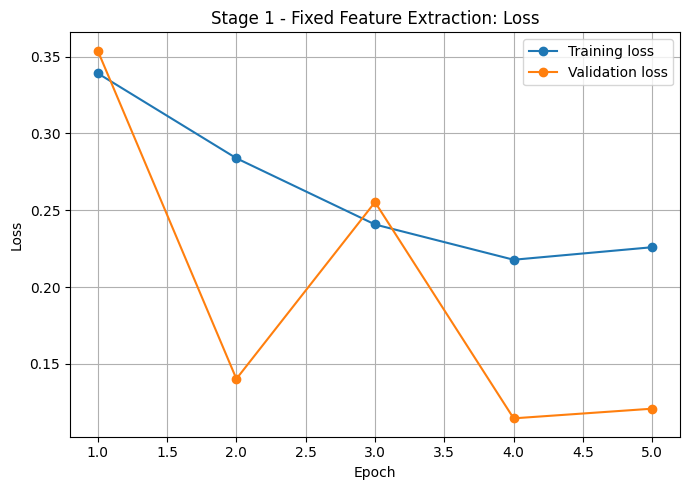

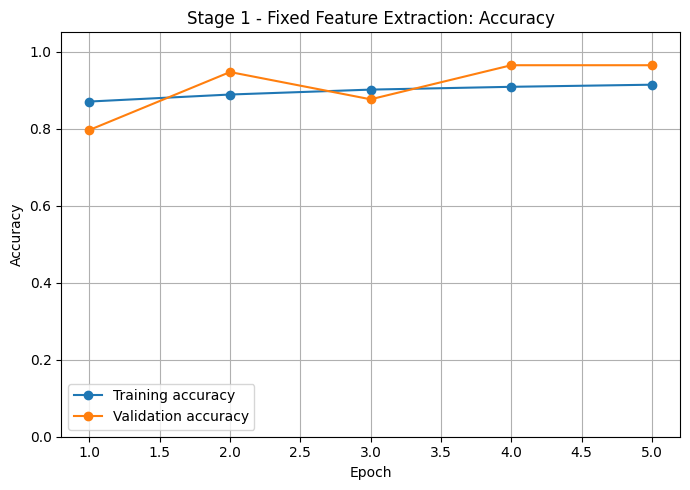

In [ ]:
def plot_history(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Training loss"
    )
    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Loss")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Training accuracy"
    )
    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


plot_history(
    stage_1_history,
    "Stage 1 - Fixed Feature Extraction"
)

# Stage 2: Partial Fine-Tuning

The final VGG16 convolution block is unfrozen. It uses a much smaller learning rate than the new classifier because the pretrained features should be adjusted carefully.

## 17. Unfreeze VGG16 Block 5 and define the fine-tuning optimizer

In [ ]:
for parameter in model.features[24:].parameters():
    parameter.requires_grad = True

stage_2_trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Stage 1 trainable parameters: {stage_1_trainable_parameters:,}")
print(f"Stage 2 trainable parameters: {stage_2_trainable_parameters:,}")

print("\nTrainable parameter groups:")
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)

stage_2_optimizer = optim.Adam([
    {
        "params": model.features[24:].parameters(),
        "lr": 0.00001
    },
    {
        "params": model.classifier[6].parameters(),
        "lr": 0.0001
    }
])

stage_2_scheduler = lr_scheduler.StepLR(
    stage_2_optimizer,
    step_size=3,
    gamma=0.1
)

Stage 1 trainable parameters: 8,194
Stage 2 trainable parameters: 7,087,618

Trainable parameter groups:
features.24.weight
features.24.bias
features.26.weight
features.26.bias
features.28.weight
features.28.bias
classifier.6.weight
classifier.6.bias


## 18. Fine-tune the final convolution block

Stage 2 | Epoch 1/5
Train loss: 0.1647 | Train accuracy: 0.9424
Val loss  : 0.0266 | Val accuracy  : 0.9823
Learning rate: 0.00001000 | Time: 29.6 s
--------------------------------------------------------------------
Stage 2 | Epoch 2/5
Train loss: 0.1028 | Train accuracy: 0.9665
Val loss  : 0.0617 | Val accuracy  : 0.9735
Learning rate: 0.00001000 | Time: 27.6 s
--------------------------------------------------------------------
Stage 2 | Epoch 3/5
Train loss: 0.0648 | Train accuracy: 0.9741
Val loss  : 0.0446 | Val accuracy  : 0.9823
Learning rate: 0.00001000 | Time: 28.4 s
--------------------------------------------------------------------
Stage 2 | Epoch 4/5
Train loss: 0.0469 | Train accuracy: 0.9843
Val loss  : 0.0238 | Val accuracy  : 0.9912
Learning rate: 0.00000100 | Time: 29.1 s
--------------------------------------------------------------------
Stage 2 | Epoch 5/5
Train loss: 0.0390 | Train accuracy: 0.9887
Val loss  : 0.0106 | Val accuracy  : 1.0000
Learning rate: 0.000

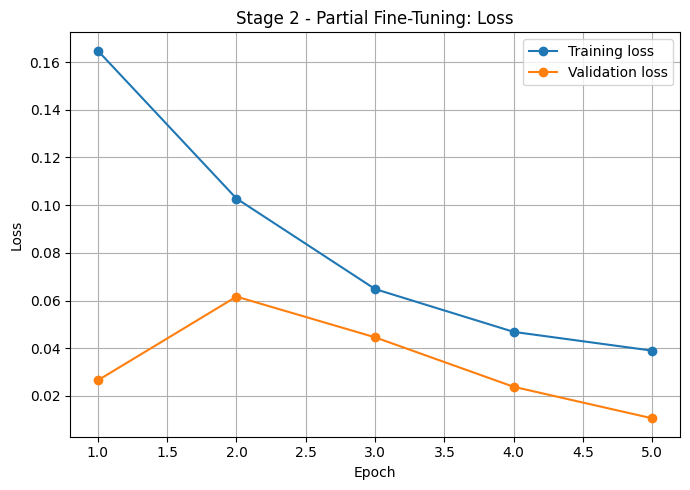

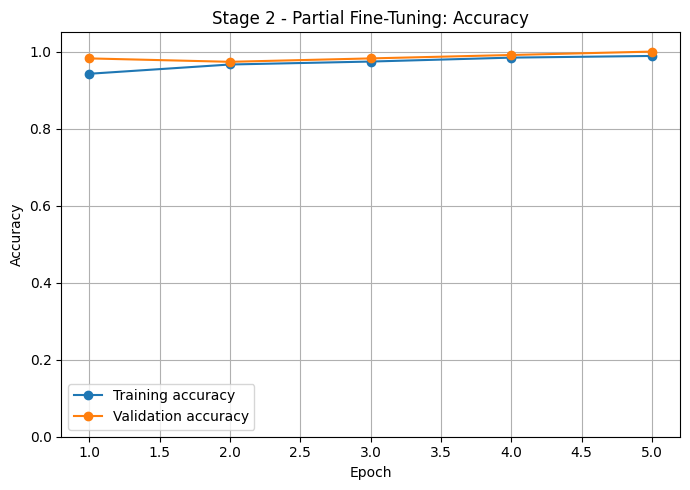

Stage 1 best validation accuracy: 0.9646017699115044
Stage 2 best validation accuracy: 1.0


In [ ]:
STAGE_2_EPOCHS = 5

(
    model,
    stage_2_history,
    stage_2_best_accuracy
) = train_model(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=stage_2_optimizer,
    device=device,
    number_of_epochs=STAGE_2_EPOCHS,
    scheduler=stage_2_scheduler,
    patience=4,
    stage_name="Stage 2"
)

plot_history(
    stage_2_history,
    "Stage 2 - Partial Fine-Tuning"
)

print("Stage 1 best validation accuracy:", stage_1_best_accuracy)
print("Stage 2 best validation accuracy:", stage_2_best_accuracy)

# Final Test Evaluation

The test set is used only after training and model selection are complete.

## 19. Evaluate the final model

In [ ]:
test_result = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test loss    : {test_result['loss']:.4f}")
print(f"Test accuracy: {test_result['accuracy']:.4f}")

print("\nClassification report:\n")
print(
    classification_report(
        test_result["labels"],
        test_result["predictions"],
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Test loss    : 0.0110
Test accuracy: 1.0000

Classification report:

              precision    recall  f1-score   support

   defective     1.0000    1.0000    1.0000        92
        good     1.0000    1.0000    1.0000        23

    accuracy                         1.0000       115
   macro avg     1.0000    1.0000    1.0000       115
weighted avg     1.0000    1.0000    1.0000       115



## 20. Display the confusion matrix

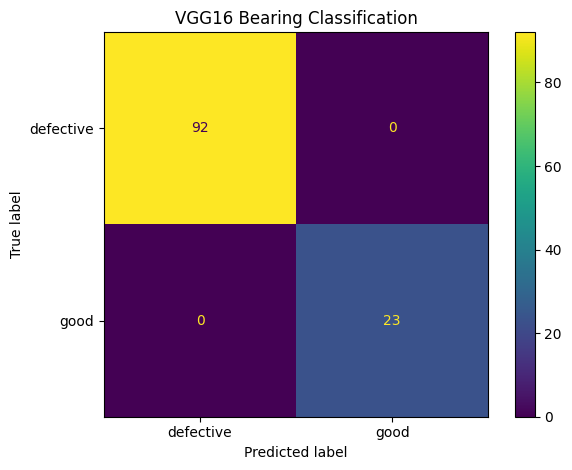

In [ ]:
confusion = confusion_matrix(
    test_result["labels"],
    test_result["predictions"]
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=class_names
)

display.plot(values_format="d")
plt.title("VGG16 Bearing Classification")
plt.tight_layout()
plt.show()

## 21. Display test predictions

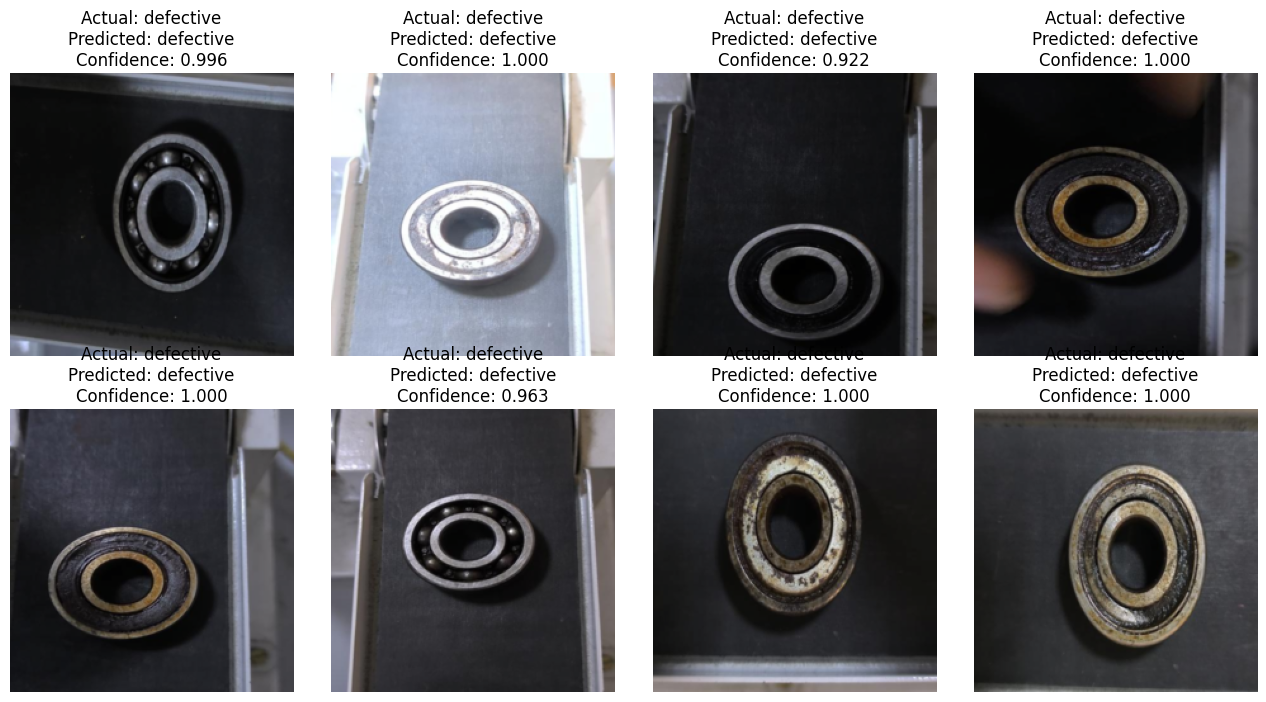

In [ ]:
def show_predictions(
    model,
    data_loader,
    class_names,
    device,
    maximum_images=8
):
    model.eval()
    images, labels = next(iter(data_loader))

    with torch.no_grad():
        outputs = model(images.to(device))
        probabilities = torch.softmax(outputs, dim=1)
        predictions = probabilities.argmax(dim=1).cpu()
        confidence = probabilities.max(dim=1).values.cpu()

    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    axes = axes.flatten()

    for index in range(min(maximum_images, len(images))):
        actual = class_names[labels[index].item()]
        predicted = class_names[predictions[index].item()]

        axes[index].imshow(
            denormalize(images[index])
        )
        axes[index].set_title(
            f"Actual: {actual}\n"
            f"Predicted: {predicted}\n"
            f"Confidence: {confidence[index]:.3f}"
        )
        axes[index].axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(
    model,
    test_loader,
    class_names,
    device
)

## 22. Display misclassified images

In [ ]:
def show_misclassified(
    dataset,
    evaluation_result,
    class_names,
    maximum_images=12
):
    labels = evaluation_result["labels"]
    predictions = evaluation_result["predictions"]
    probabilities = evaluation_result["probabilities"]

    incorrect_indices = np.where(
        labels != predictions
    )[0]

    print(
        "Number of misclassified images:",
        len(incorrect_indices)
    )

    if len(incorrect_indices) == 0:
        return

    selected = incorrect_indices[:maximum_images]
    columns = 4
    rows = int(np.ceil(len(selected) / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(14, 3.5 * rows)
    )
    axes = np.array(axes).reshape(-1)

    for plot_index, dataset_index in enumerate(selected):
        image_path, _ = dataset.samples[dataset_index]
        image = Image.open(image_path).convert("RGB")

        actual_index = labels[dataset_index]
        predicted_index = predictions[dataset_index]
        confidence = probabilities[
            dataset_index,
            predicted_index
        ]

        axes[plot_index].imshow(image)
        axes[plot_index].set_title(
            f"Actual: {class_names[actual_index]}\n"
            f"Predicted: {class_names[predicted_index]}\n"
            f"Confidence: {confidence:.3f}"
        )
        axes[plot_index].axis("off")

    for index in range(len(selected), len(axes)):
        axes[index].axis("off")

    plt.tight_layout()
    plt.show()


show_misclassified(
    test_dataset,
    test_result,
    class_names
)

Number of misclassified images: 0


## 23. Save the trained model to Google Drive

In [ ]:
DRIVE_PROJECT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_SAVE_PATH = (
    DRIVE_PROJECT_DIR
    / "vgg16_bearing_good_defective.pth"
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "image_size": IMAGE_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "stage_1_best_validation_accuracy": stage_1_best_accuracy,
    "stage_2_best_validation_accuracy": stage_2_best_accuracy,
    "test_accuracy": test_result["accuracy"]
}

torch.save(checkpoint, MODEL_SAVE_PATH)

print("Model saved to:")
print(MODEL_SAVE_PATH)

Model saved to:
/content/drive/MyDrive/CNN_Transfer_Learning/vgg16_bearing_good_defective.pth


# Final Prediction on a New Bearing Image

## 24. Define the prediction function

In [ ]:
def predict_single_image(
    model,
    image_path,
    transform,
    class_names,
    device
):
    model.eval()

    image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)[0]

    predicted_index = probabilities.argmax().item()

    return {
        "image": image,
        "predicted_class": class_names[predicted_index],
        "confidence": probabilities[predicted_index].item(),
        "probabilities": {
            class_names[index]: probabilities[index].item()
            for index in range(len(class_names))
        }
    }

## 25. Upload an image and predict its class

Saving img.png to img (1).png
Predicted class: defective
Confidence     : 0.9993

Class probabilities:
defective   : 0.9993
good        : 0.0007


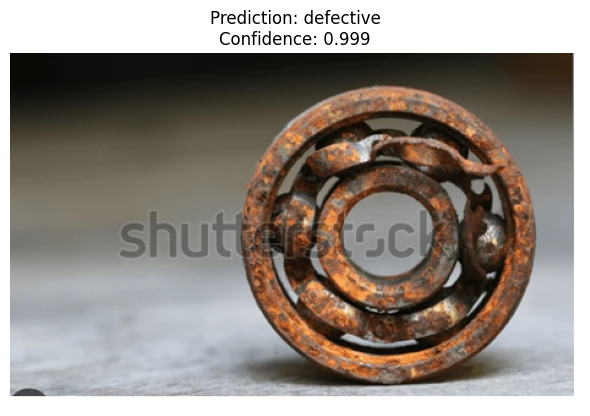

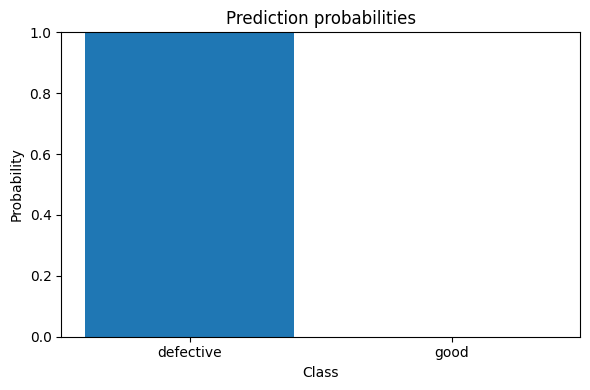

In [ ]:
from google.colab import files

uploaded_files = files.upload()

if len(uploaded_files) == 0:
    raise RuntimeError("No image was uploaded.")

uploaded_name = next(iter(uploaded_files))
uploaded_path = Path("/content") / uploaded_name

prediction = predict_single_image(
    model=model,
    image_path=uploaded_path,
    transform=evaluation_transform,
    class_names=class_names,
    device=device
)

print("Predicted class:", prediction["predicted_class"])
print("Confidence     :", f"{prediction['confidence']:.4f}")

print("\nClass probabilities:")
for class_name, probability in prediction["probabilities"].items():
    print(f"{class_name:<12}: {probability:.4f}")

plt.figure(figsize=(6, 5))
plt.imshow(prediction["image"])
plt.title(
    f"Prediction: {prediction['predicted_class']}\n"
    f"Confidence: {prediction['confidence']:.3f}"
)
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(
    list(prediction["probabilities"].keys()),
    list(prediction["probabilities"].values())
)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Probability")
plt.title("Prediction probabilities")
plt.tight_layout()
plt.show()

## 26. Optional: reload the saved model in a future Colab session

In [ ]:
def load_saved_vgg16(
    checkpoint_path,
    device
):
    saved = torch.load(
        checkpoint_path,
        map_location=device
    )

    saved_class_names = saved["class_names"]

    loaded_model = vgg16(weights=None)
    input_features = loaded_model.classifier[6].in_features

    loaded_model.classifier[6] = nn.Linear(
        input_features,
        len(saved_class_names)
    )

    loaded_model.load_state_dict(
        saved["model_state_dict"]
    )

    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    return loaded_model, saved


reloaded_model, reloaded_checkpoint = load_saved_vgg16(
    MODEL_SAVE_PATH,
    device
)

print("Reloaded classes:", reloaded_checkpoint["class_names"])
print("Saved test accuracy:", reloaded_checkpoint["test_accuracy"])

Reloaded classes: ['defective', 'good']
Saved test accuracy: 1.0


# Interpretation

## Stage 1: frozen feature extractor

Only the new final layer is trained.

Advantages:

- fast
- few trainable parameters
- lower overfitting risk
- suitable for a small dataset

## Stage 2: partial fine-tuning

The final VGG16 convolution block and the new output layer are trained.

Advantages:

- deeper features can adapt to bearing surfaces and defects
- may improve validation and test performance

Risks:

- slower training
- greater overfitting risk
- pretrained layers require a smaller learning rate

## Important engineering questions

1. What is the recall of the `defective` class?
2. How many defective bearings are predicted as good?
3. Are errors caused by the model, labels, lighting, or camera position?
4. Is confidence reliable on ambiguous images?
5. Is VGG16 fast enough for the intended deployment hardware?

# References

- PyTorch transfer-learning tutorial:  
  https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial

- TorchVision pretrained models and weights:  
  https://docs.pytorch.org/vision/stable/models.html

- TorchVision ImageFolder:  
  https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html